<a href="https://colab.research.google.com/github/Danielrlins/Workshop26.1/blob/main/Desafio_Final_WKS_26.1/Python/ml_python_desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# --- EXTRAÇÃO ---
df = pd.read_csv('pneumologista_joao_pacientes.csv')

# --- TRANSFORMAÇÃO ---
# 1. Tratar nulos (Saturação, Peso e Altura)
df['saturacao_oxigenio'] = df['saturacao_oxigenio'].fillna(df['saturacao_oxigenio'].mean())
df['peso_kg'] = df['peso_kg'].fillna(df['peso_kg'].median())
df['altura_m'] = df['altura_m'].fillna(df['altura_m'].median())

# 2. Padronizar a coluna Sexo
def padronizar_sexo(valor):
    valor = str(valor).upper().strip()
    if valor in ['MASCULINO', 'MASC', 'M']: return 'M'
    if valor in ['FEMININO', 'FEM', 'F']: return 'F'
    return 'Outro' # Para o "Não declarado"

df['sexo'] = df['sexo'].apply(padronizar_sexo)

# 3. Recalcular/Validar IMC (Peso / Altura²)
df['imc_calculado'] = df['peso_kg'] / (df['altura_m'] ** 2)

#Tratar saturação
# --- LIMPEZA DA SATURAÇÃO DE OXIGÊNIO ---

# 1. Remover valores absurdos
df = df[df['saturacao_oxigenio'] < 1000]

# 2. Corrigir escala (ex: 950 → 95)
df['saturacao_oxigenio'] = df['saturacao_oxigenio'].apply(
    lambda x: x / 10 if x > 100 else x
)

# 3. Filtrar valores realistas
df = df[(df['saturacao_oxigenio'] >= 85) &
        (df['saturacao_oxigenio'] <= 100)]


# --- CARGA ---
df.to_csv('pacientes_clinica_limpo.csv', index=False)
print("ETL Concluído. Arquivo limpo salvo!")

ETL Concluído. Arquivo limpo salvo!


In [ ]:
import numpy as np

# 1. Carregar os dados limpos
df_clean = pd.read_csv('pacientes_clinica_limpo.csv')


media_imc = np.mean(df_clean['imc_calculado'])
desvio_imc = np.std(df_clean['imc_calculado'])

print(f"Média do IMC: {media_imc:.2f}")
print(f"Desvio padrão do IMC: {desvio_imc:.2f}")


Média do IMC: 27.14
Desvio padrão do IMC: 6.12


/tmp/ipykernel_455/740304931.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem.index, y=contagem.values, palette=['#4CAF50', '#FF5252'], edgecolor='black')


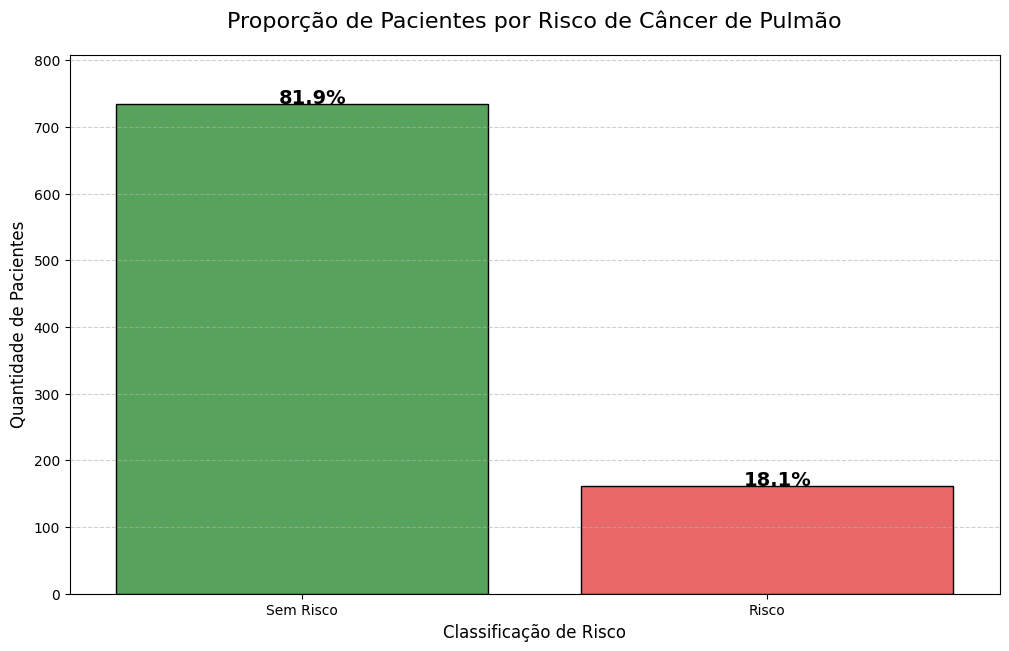

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df_clean = pd.read_csv('pacientes_clinica_limpo.csv')


# Configuração de tamanho grande
plt.figure(figsize=(12, 7))

# Calculando a contagem e porcentagem
contagem = df_clean['risco_cancer_pulmao'].value_counts()
total = len(df_clean)

# Criando o gráfico de barras
ax = sns.barplot(x=contagem.index, y=contagem.values, palette=['#4CAF50', '#FF5252'], edgecolor='black')

# Adicionando os rótulos de porcentagem em cima das barras
for p in ax.patches:
    porcentagem = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 0.5
    ax.annotate(porcentagem, (x, y), size=14, fontweight='bold')

plt.title('Proporção de Pacientes por Risco de Câncer de Pulmão', fontsize=16, pad=20)
plt.xlabel('Classificação de Risco', fontsize=12)
plt.ylabel('Quantidade de Pacientes', fontsize=12)
plt.ylim(0, max(contagem.values) * 1.1) # Aumenta o limite do eixo Y para caber o texto
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

/tmp/ipykernel_455/3218671950.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem_faixa.index, y=contagem_faixa.values, palette='YlOrRd', edgecolor='black')


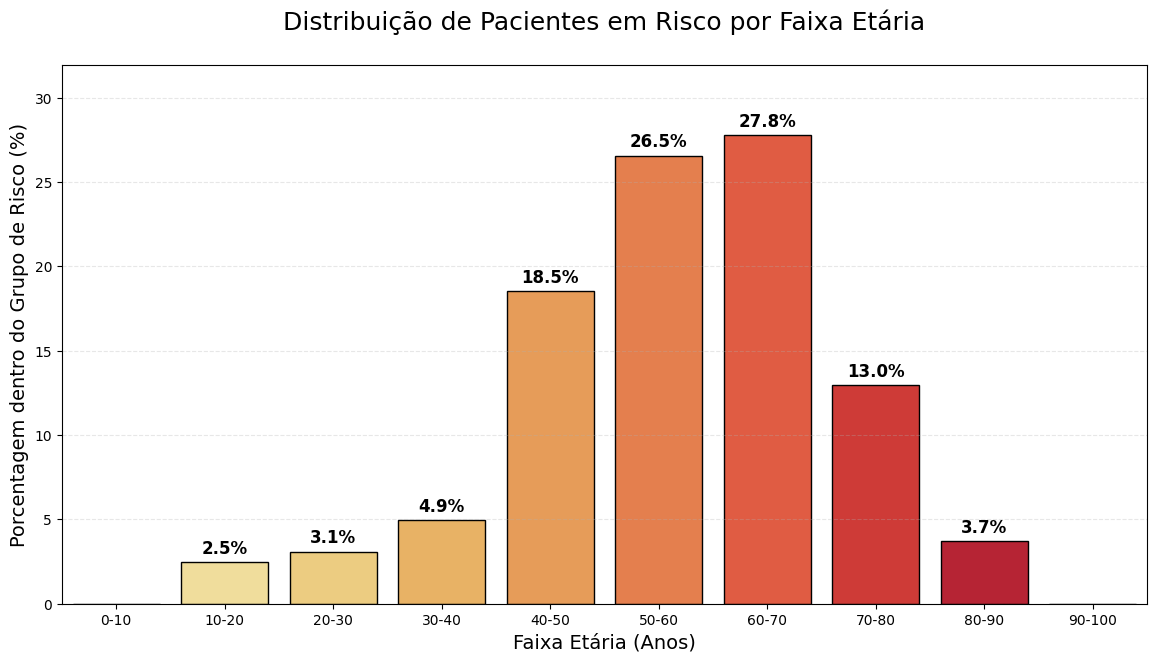

In [ ]:
# --- CÉLULA DE CÓDIGO: RISCO POR FAIXA ETÁRIA ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar apenas pacientes com Risco
df_risco = df_clean[df_clean['risco_cancer_pulmao'] == 'Risco'].copy()

# 2. Criar as faixas etárias (bins) de 10 em 10 anos
# Definimos os cortes: 0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100
bins = list(range(0, 110, 10))
labels = [f'{i}-{i+10}' for i in range(0, 100, 10)]

df_risco['faixa_etaria'] = pd.cut(df_risco['idade'], bins=bins, labels=labels, right=False)

# 3. Calcular a porcentagem por faixa
contagem_faixa = df_risco['faixa_etaria'].value_counts(normalize=True).sort_index() * 100

# 4. Configurar o gráfico grande
plt.figure(figsize=(14, 7))

# Criando o gráfico de barras (usando uma paleta de cores sequencial para indicar idade)
ax = sns.barplot(x=contagem_faixa.index, y=contagem_faixa.values, palette='YlOrRd', edgecolor='black')

# Adicionando os rótulos de porcentagem
for p in ax.patches:
    if p.get_height() > 0: # Só mostra se a porcentagem for maior que zero
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')

# Customização do Dr. João
plt.title('Distribuição de Pacientes em Risco por Faixa Etária', fontsize=18, pad=25)
plt.xlabel('Faixa Etária (Anos)', fontsize=14)
plt.ylabel('Porcentagem dentro do Grupo de Risco (%)', fontsize=14)
plt.ylim(0, max(contagem_faixa.values) * 1.15) # Espaço para o texto
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

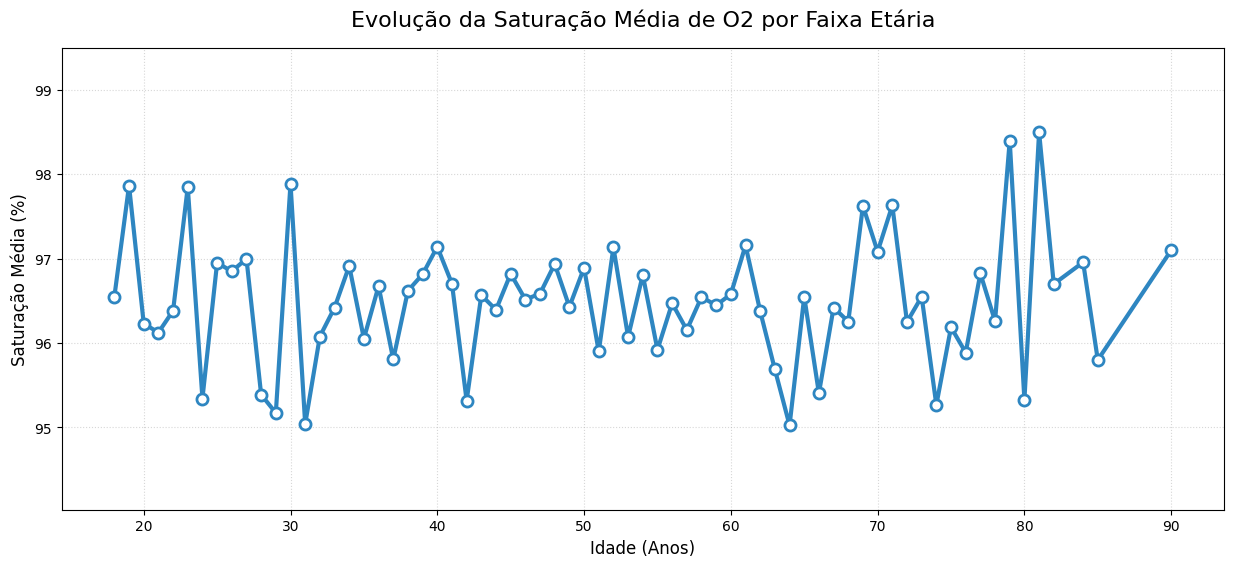

In [ ]:
# --- CÉLULA DE CÓDIGO: GRÁFICO DE LINHA ---
import matplotlib.pyplot as plt

# Agrupando os dados limpos para pegar a média por idade
tendencia_sat = df_clean.groupby('idade')['saturacao_oxigenio'].mean()

plt.figure(figsize=(15, 6))

# Criando a linha com marcadores
plt.plot(tendencia_sat.index, tendencia_sat.values,
         color='#2E86C1',
         linestyle='-',
         linewidth=3,
         marker='o',
         markersize=8,
         markerfacecolor='white',
         markeredgewidth=2)

# Customização visual
plt.title('Evolução da Saturação Média de O2 por Faixa Etária', fontsize=16, pad=15)
plt.xlabel('Idade (Anos)', fontsize=12)
plt.ylabel('Saturação Média (%)', fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.5)

# Definindo os limites do eixo Y para destacar pequenas variações (comum em saúde)
min_sat = tendencia_sat.min() - 1
max_sat = tendencia_sat.max() + 1
plt.ylim(min_sat, max_sat)

plt.show()

--- RESULTADOS DO MODELO (DR. JOÃO) ---
Acurácia Geral: 82.22%

Relatório Detalhado:
              precision    recall  f1-score   support

       Risco       0.59      0.36      0.45        36
   Sem Risco       0.85      0.94      0.89       144

    accuracy                           0.82       180
   macro avg       0.72      0.65      0.67       180
weighted avg       0.80      0.82      0.80       180



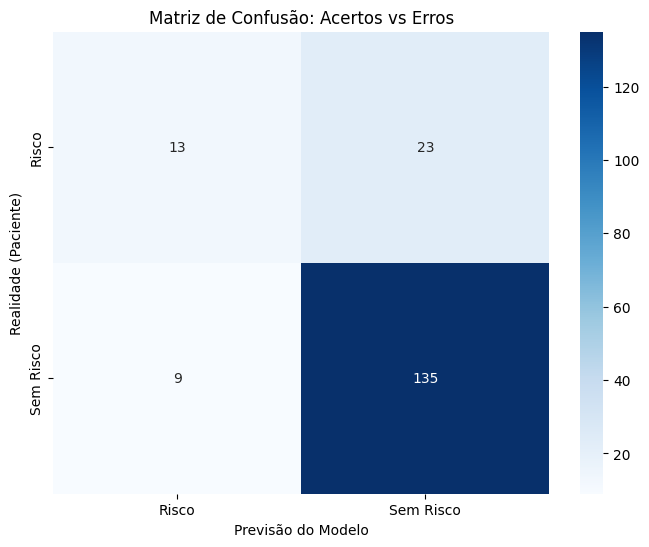

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# 1. Preparação dos dados (Transformar texto em número)
df_ml = df_clean.copy()

# Criando um dicionário para converter Sim/Não em 1/0
mapeamento = {'Sim': 1, 'Não': 0}
colunas_binarias = ['tabagismo', 'doenca_cronica', 'historico_familiar', 'doenca_pulmonar']

for col in colunas_binarias:
    df_ml[col] = df_ml[col].map(mapeamento)

# Converter Sexo (M=0, F=1, Outro=2)
df_ml['sexo_n'] = df_ml['sexo'].map({'M': 0, 'F': 1, 'Outro': 2})

# 2. Definir Features (X) e Alvo (y)
# Escolhemos as colunas que mais influenciam o risco
X = df_ml[['idade', 'sexo_n', 'tabagismo', 'saturacao_oxigenio', 'imc_calculado', 'doenca_cronica']]
y = df_ml['risco_cancer_pulmao']

# 3. Separar dados em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Criar e Treinar o Modelo (Random Forest)
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 5. Fazer Previsões
y_pred = modelo.predict(X_test)

# Acuracia e resultados
acuracia = accuracy_score(y_test, y_pred)

print(f"--- RESULTADOS DO MODELO (DR. JOÃO) ---")
print(f"Acurácia Geral: {acuracia * 100:.2f}%")
print("\nRelatório Detalhado:")
print(classification_report(y_test, y_pred))

# Visualizar a Matriz de Confusão (Onde o modelo acertou ou errou)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.title('Matriz de Confusão: Acertos vs Erros')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Realidade (Paciente)')
plt.show()